In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

In [5]:
df= pd.read_csv("/content/Day18_19_student_habits_performance.csv")
print(df.shape)
df.head()

(1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [7]:
numerical_features = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
                      "attendance_percentage", "sleep_hours", "exercise_frequency",
                      "mental_health_rating"]
categorical_features = ["gender", "part_time_job", "diet_quality", "parental_education_level",
                         "internet_quality", "extracurricular_participation"]
target = "exam_score"

print(f"Numerical features ({len(numerical_features)}):", numerical_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)
print(f"Target: {target}")

Numerical features (8): ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features (6): ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
Target: exam_score


In [10]:
print("no.of missing values :\n", df.isnull().sum())

no.of missing values :
 student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [11]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate student_id values:", df['student_id'].duplicated().sum())

Fully duplicated rows: 0
Duplicate student_id values: 0


In [12]:
df[numerical_features + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


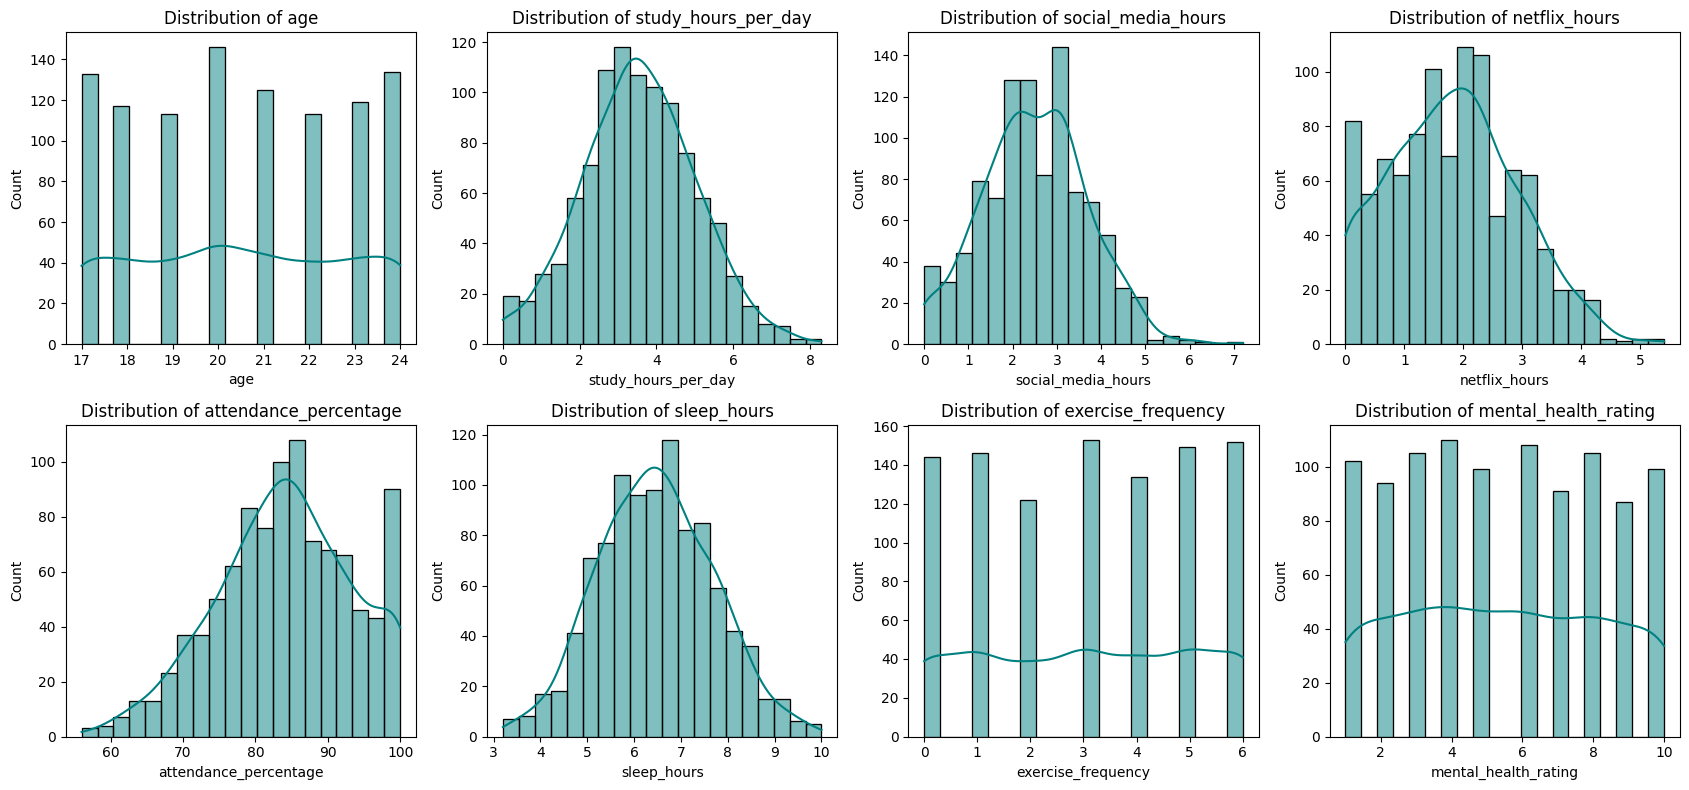

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, col in zip(axes.flat, numerical_features):
    sns.histplot(df[col], bins=20, kde=True, color="teal", ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

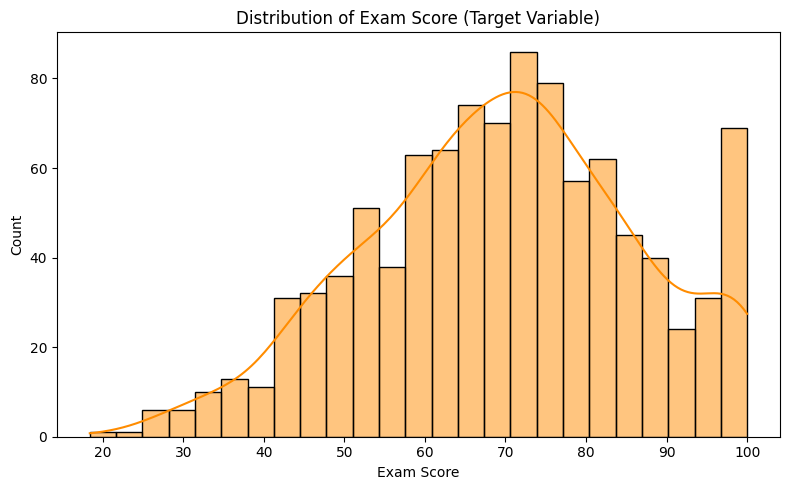

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df[target], bins=25, kde=True, color="darkorange", ax=ax)
ax.set_title("Distribution of Exam Score (Target Variable)")
ax.set_xlabel("Exam Score")
plt.tight_layout()
plt.show()

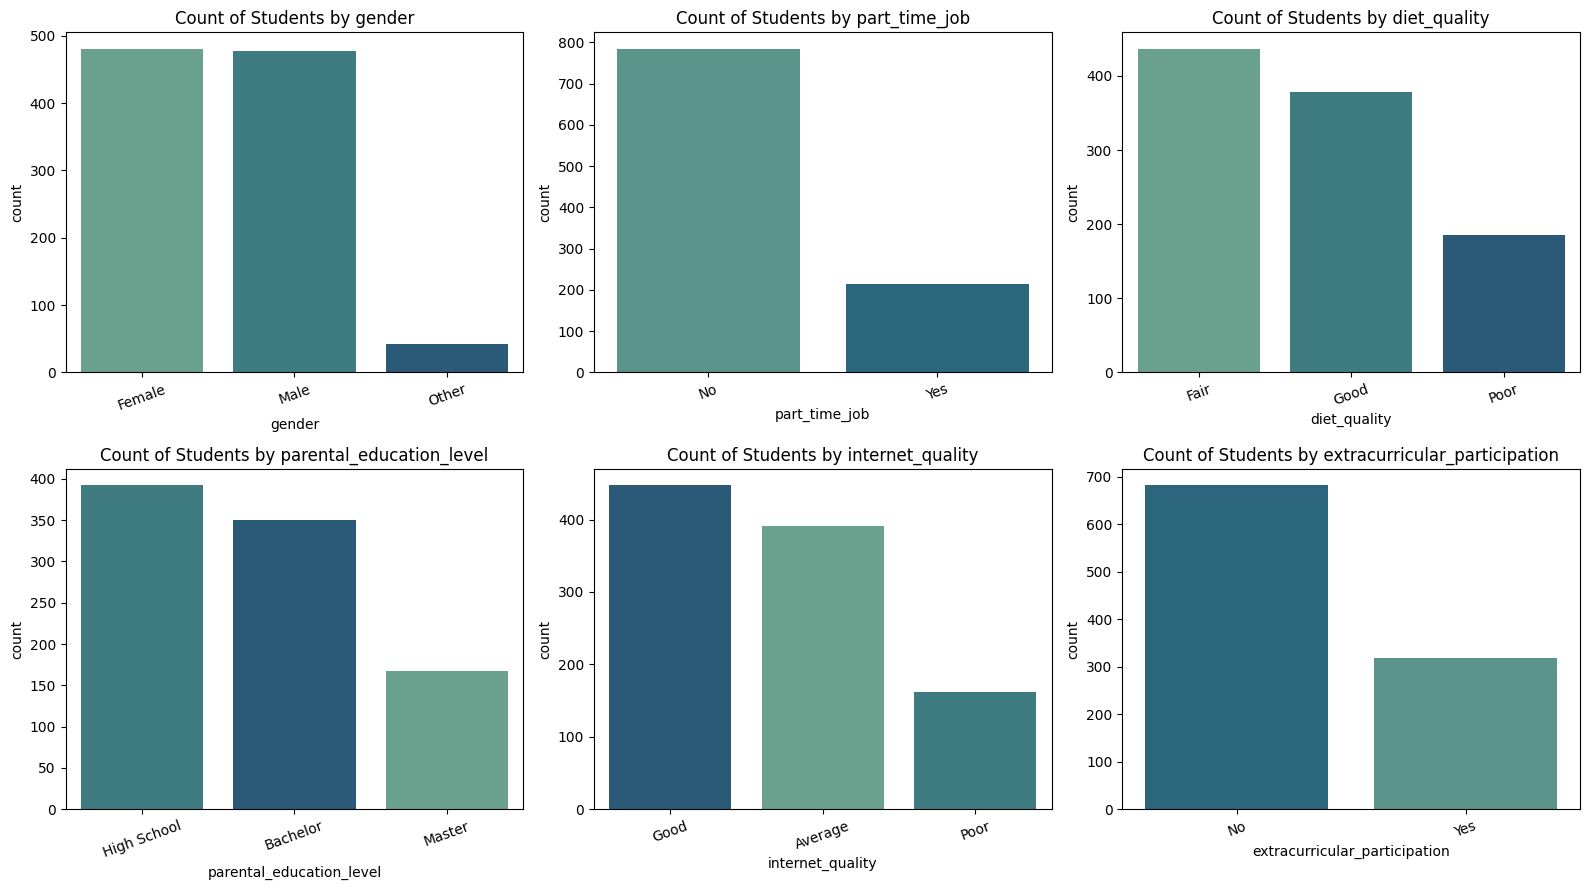

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette="crest", legend=False, ax=ax)
    ax.set_title(f"Count of Students by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

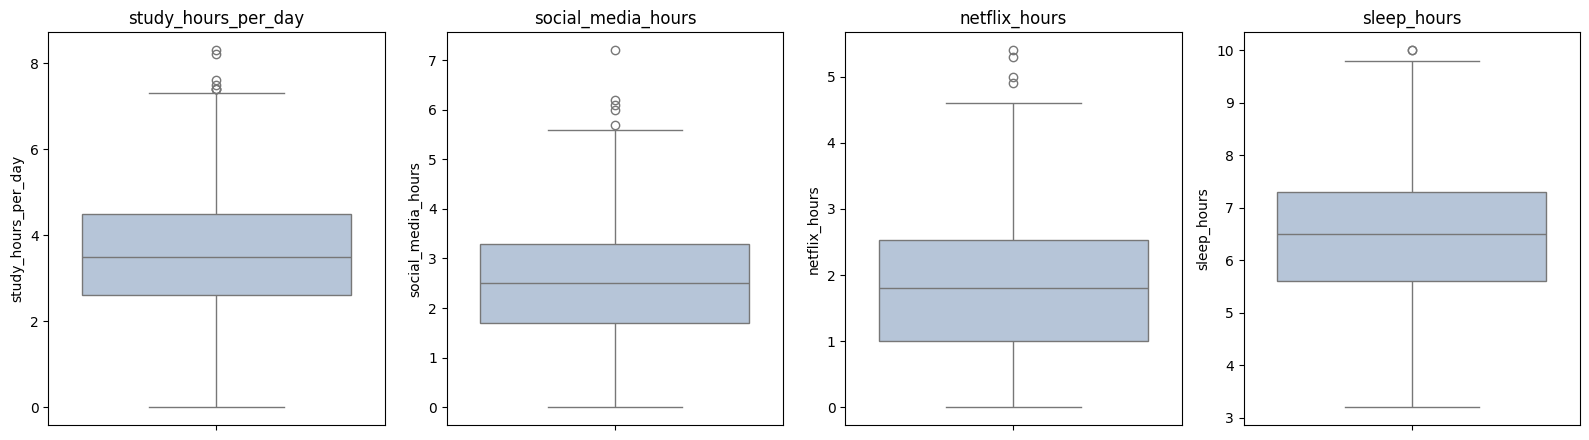

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, ["study_hours_per_day", "social_media_hours", "netflix_hours", "sleep_hours"]):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [17]:
print(f"{'Column':<24}{'Outliers':>10}{'% of data':>12}")
for col in numerical_features + [target]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:<24}{n_out:>10}{n_out/len(df)*100:>11.1f}%")

Column                    Outliers   % of data
age                              0        0.0%
study_hours_per_day              7        0.7%
social_media_hours               5        0.5%
netflix_hours                    4        0.4%
attendance_percentage            3        0.3%
sleep_hours                      2        0.2%
exercise_frequency               0        0.0%
mental_health_rating             0        0.0%
exam_score                       2        0.2%


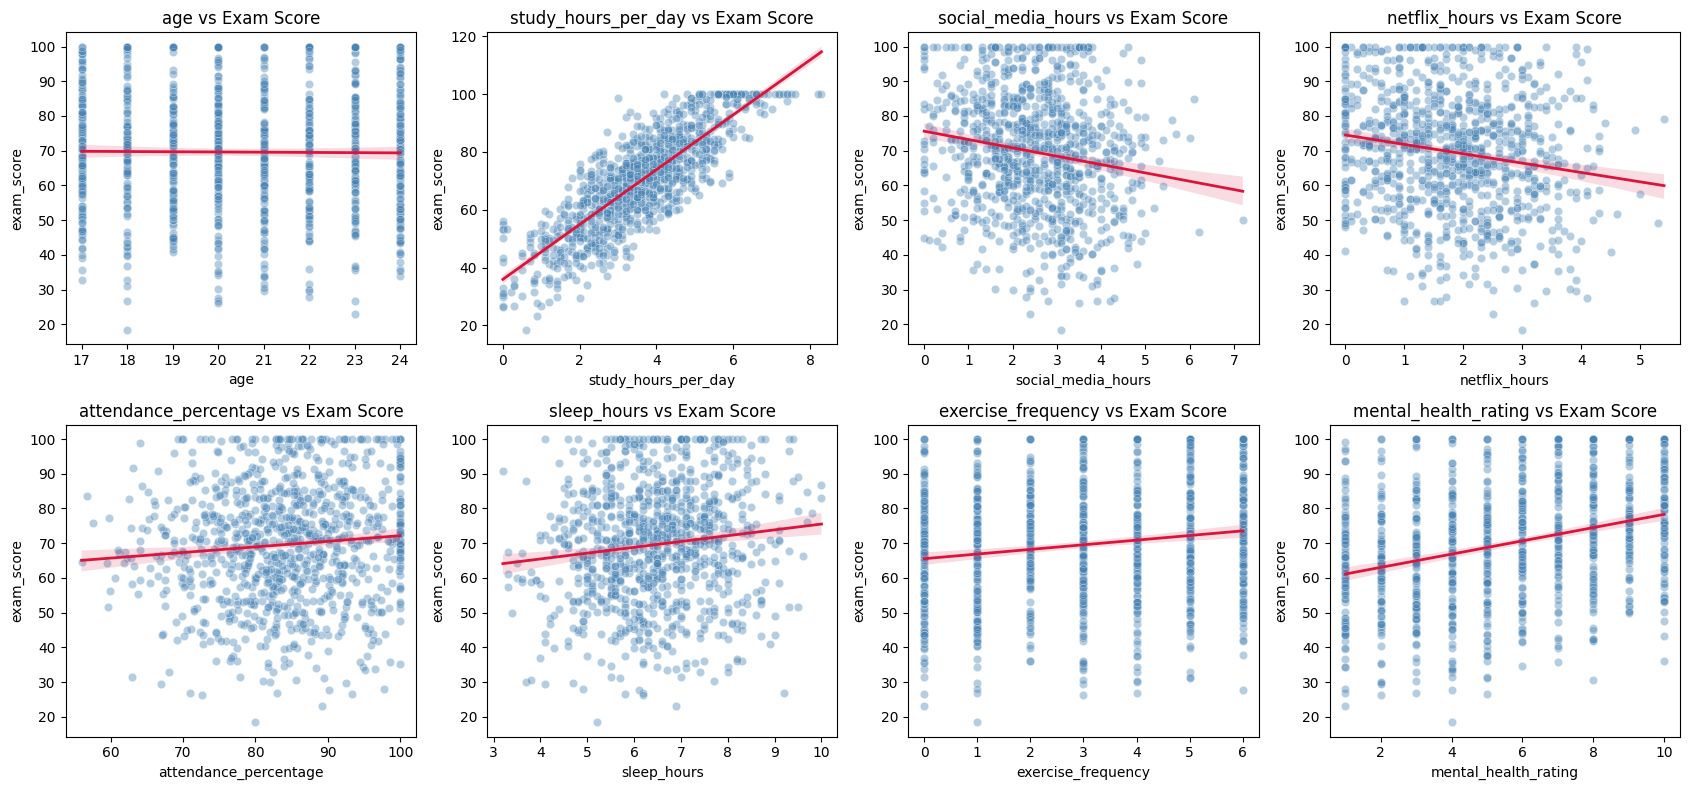

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, col in zip(axes.flat, numerical_features):
    sns.scatterplot(data=df, x=col, y=target, alpha=0.4, color="steelblue", ax=ax)
    sns.regplot(data=df, x=col, y=target, scatter=False, color="crimson", ax=ax, line_kws={"linewidth": 2})
    ax.set_title(f"{col} vs Exam Score")
plt.tight_layout()
plt.show()

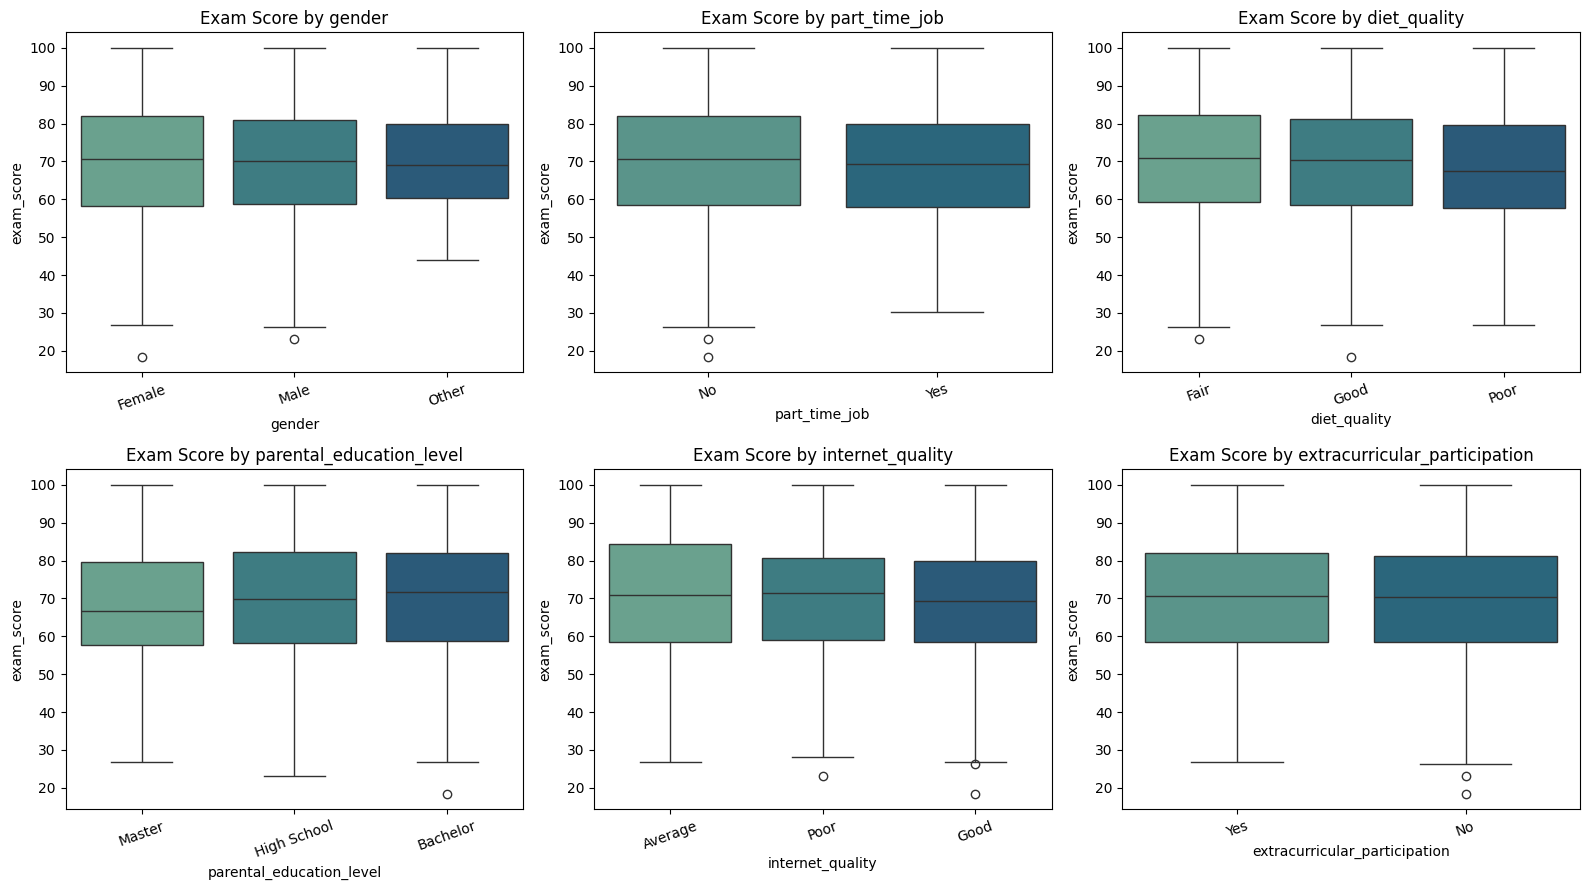

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, categorical_features):
    sns.boxplot(data=df, x=col, y=target, hue=col, palette="crest", legend=False, ax=ax)
    ax.set_title(f"Exam Score by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

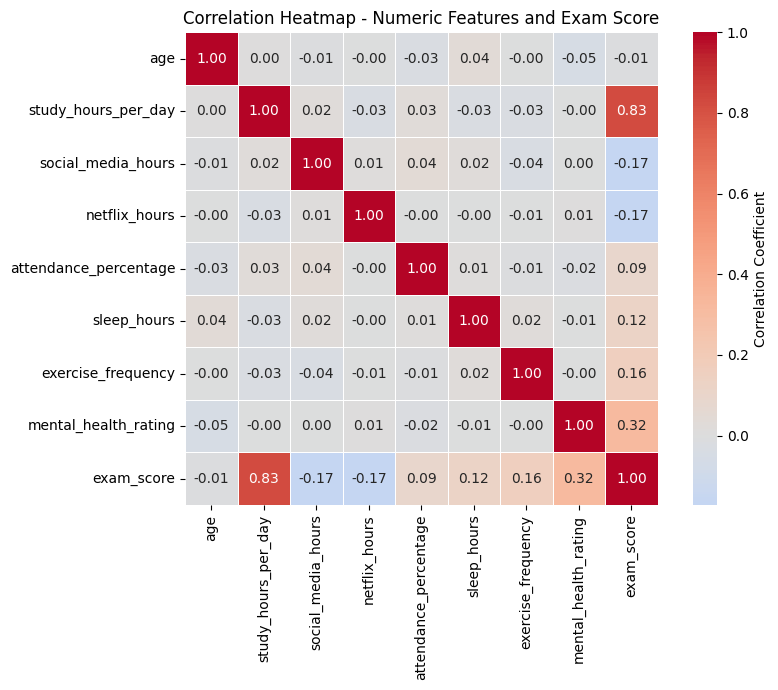

In [20]:
corr_matrix = df[numerical_features + [target]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"}, ax=ax)
ax.set_title("Correlation Heatmap - Numeric Features and Exam Score")
plt.tight_layout()
plt.show()

In [21]:
ml_df = df.copy()

ml_df["parental_education_level"] = ml_df["parental_education_level"].fillna("Unknown")

print("Remaining missing values:", ml_df.isnull().sum().sum())

Remaining missing values: 0


In [22]:
ml_df = ml_df.drop(columns=["student_id"])

feature_numerical = ["age", "study_hours_per_day", "attendance_percentage", "sleep_hours",
                      "social_media_hours", "netflix_hours", "exercise_frequency",
                      "mental_health_rating"]
feature_categorical = ["gender", "part_time_job", "diet_quality", "parental_education_level",
                        "internet_quality", "extracurricular_participation"]

print("Numerical features used:", feature_numerical)
print("Categorical features used:", feature_categorical)

Numerical features used: ['age', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features used: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [23]:
encoded_categorical = pd.get_dummies(ml_df[feature_categorical], drop_first=True)

X = pd.concat([ml_df[feature_numerical], encoded_categorical], axis=1)
y_reg = ml_df["exam_score"]

print("Final feature matrix shape:", X.shape)
X.head()

Final feature matrix shape: (1000, 19)


,age,study_hours_per_day,attendance_percentage,sleep_hours,social_media_hours,netflix_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,85.0,8.0,1.2,1.1,6,8,False,False,False,False,False,False,True,False,False,False,True
1,20,6.9,97.3,4.6,2.8,2.3,6,8,False,False,False,True,False,True,False,False,False,False,False
2,21,1.4,94.8,8.0,3.1,1.3,1,1,True,False,False,False,True,True,False,False,False,True,False
3,23,1.0,71.0,9.2,3.9,1.0,4,1,False,False,False,False,True,False,True,False,True,False,True
4,19,5.0,90.9,4.9,4.4,0.5,3,1,False,False,False,False,False,False,True,False,True,False,False


In [25]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 19)
Test set: (200, 19)


In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_reg)

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print("Model trained.")

Model trained.


In [27]:
def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.4f}")
    print()
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_train_reg, y_train_pred, "Training Set")
test_metrics = regression_report(y_test_reg, y_test_pred, "Test Set")

--- Training Set ---
MAE  : 4.212
MSE  : 28.555
RMSE : 5.344
R2   : 0.9021

--- Test Set ---
MAE  : 4.189
MSE  : 26.476
RMSE : 5.146
R2   : 0.8968



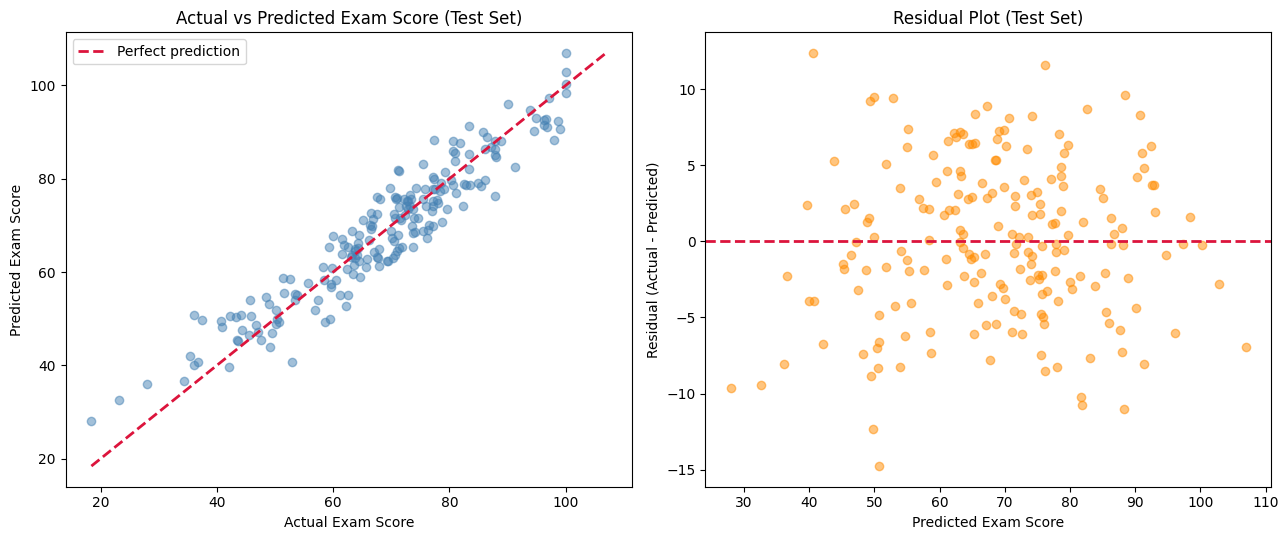

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_test_reg, y_test_pred, alpha=0.5, color="steelblue")
lims = [min(y_test_reg.min(), y_test_pred.min()), max(y_test_reg.max(), y_test_pred.max())]
axes[0].plot(lims, lims, color="crimson", linestyle="--", linewidth=2, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted Exam Score (Test Set)")
axes[0].set_xlabel("Actual Exam Score")
axes[0].set_ylabel("Predicted Exam Score")
axes[0].legend()

residuals = y_test_reg - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, color="darkorange")
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Residual Plot (Test Set)")
axes[1].set_xlabel("Predicted Exam Score")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

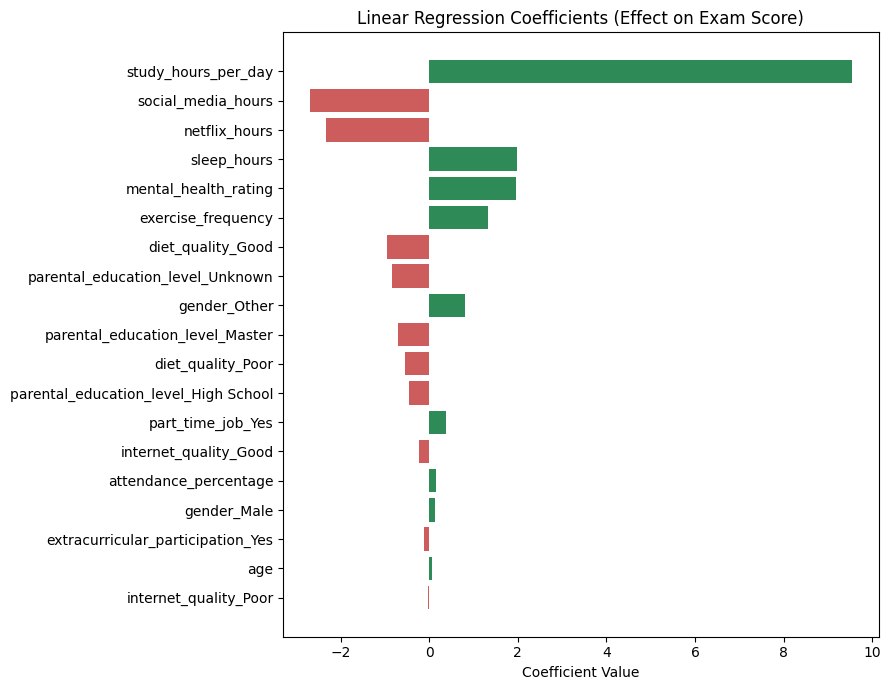

In [29]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["seagreen" if c > 0 else "indianred" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.set_title("Linear Regression Coefficients (Effect on Exam Score)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

exam_score
Pass    869
Fail    131
Name: count, dtype: int64

Pass rate: 86.9%


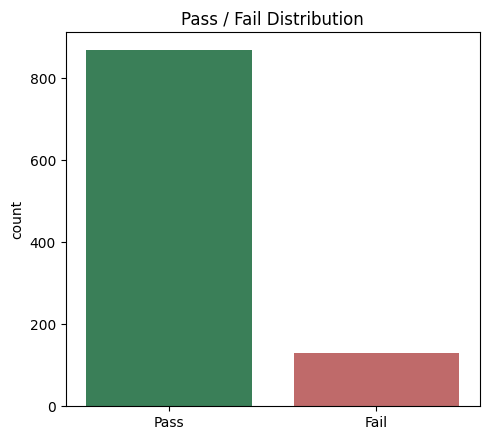

In [30]:
y_class = (ml_df["exam_score"] >= 50).astype(int)

class_counts = y_class.value_counts().rename({1: "Pass", 0: "Fail"})
print(class_counts)
print(f"\nPass rate: {y_class.mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.countplot(x=y_class.map({1: "Pass", 0: "Fail"}), hue=y_class.map({1: "Pass", 0: "Fail"}),
              palette={"Pass": "seagreen", "Fail": "indianred"}, legend=False, ax=ax)
ax.set_title("Pass / Fail Distribution")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [32]:
X_train_c, X_test_c, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Training set:", X_train_c.shape, "| Pass rate:", y_train_class.mean().round(3))
print("Test set:", X_test_c.shape, "| Pass rate:", y_test_class.mean().round(3))

Training set: (800, 19) | Pass rate: 0.869
Test set: (200, 19) | Pass rate: 0.87


In [33]:
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Features scaled. Training mean (should be ~0):", X_train_c_scaled.mean().round(3))

Features scaled. Training mean (should be ~0): -0.0


In [34]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_scaled, y_train_class)

y_train_class_pred = log_reg.predict(X_train_c_scaled)
y_test_class_pred = log_reg.predict(X_test_c_scaled)

print("Model trained.")

Model trained.


In [35]:
def classification_report_summary(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print()
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

train_class_metrics = classification_report_summary(y_train_class, y_train_class_pred, "Training Set")
test_class_metrics = classification_report_summary(y_test_class, y_test_class_pred, "Test Set")

print("Full classification report (test set):")
print(classification_report(y_test_class, y_test_class_pred, target_names=["Fail", "Pass"]))

--- Training Set ---
Accuracy  : 0.9587
Precision : 0.9702
Recall    : 0.9827
F1-score  : 0.9764

--- Test Set ---
Accuracy  : 0.9500
Precision : 0.9659
Recall    : 0.9770
F1-score  : 0.9714

Full classification report (test set):
              precision    recall  f1-score   support

        Fail       0.83      0.77      0.80        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.90      0.87      0.89       200
weighted avg       0.95      0.95      0.95       200



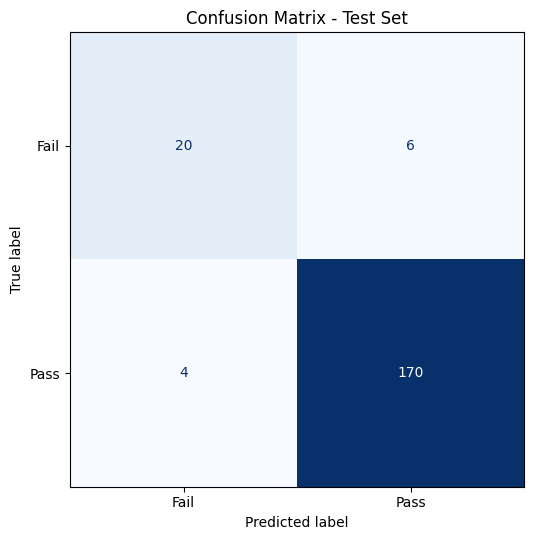

In [36]:
cm = confusion_matrix(y_test_class, y_test_class_pred)

fig, ax = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [37]:
reg_comparison = pd.DataFrame({"Train": train_metrics, "Test": test_metrics}).round(3)
reg_comparison.loc["R2"] = reg_comparison.loc["R2"].round(4)
print("Regression - Train vs Test:")
reg_comparison

Regression - Train vs Test:


,Train,Test
MAE,4.212,4.189
MSE,28.555,26.476
RMSE,5.344,5.146
R2,0.902,0.897


In [38]:
class_comparison = pd.DataFrame({"Train": train_class_metrics, "Test": test_class_metrics}).round(4)
print("Classification - Train vs Test:")
class_comparison


Classification - Train vs Test:


,Train,Test
Accuracy,0.9588,0.9500
Precision,0.9702,0.9659
Recall,0.9827,0.9770
F1,0.9764,0.9714


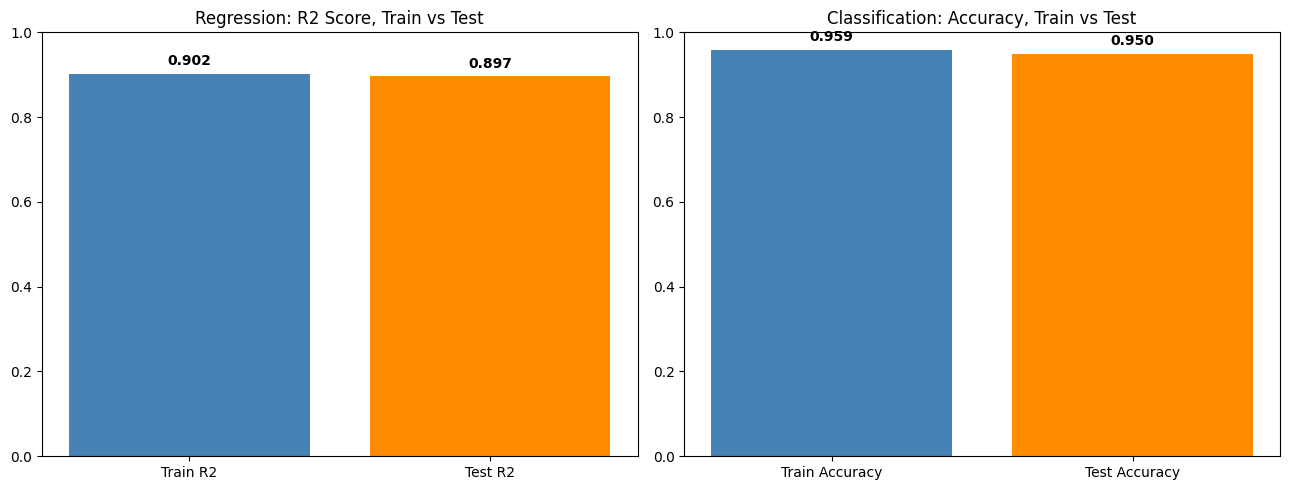

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(["Train R2", "Test R2"], [train_metrics["R2"], test_metrics["R2"]],
            color=["steelblue", "darkorange"])
axes[0].set_title("Regression: R2 Score, Train vs Test")
axes[0].set_ylim(0, 1)
for i, v in enumerate([train_metrics["R2"], test_metrics["R2"]]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(["Train Accuracy", "Test Accuracy"],
            [train_class_metrics["Accuracy"], test_class_metrics["Accuracy"]],
            color=["steelblue", "darkorange"])
axes[1].set_title("Classification: Accuracy, Train vs Test")
axes[1].set_ylim(0, 1)
for i, v in enumerate([train_class_metrics["Accuracy"], test_class_metrics["Accuracy"]]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()